# NT EDA

In this project, feature ideas are developed from EDA findings.

Main questions:

1. What are the main NT tables and how large are they?
2. How do the normal and abnormal pools differ?
3. Are there missing-value, duplication, or join-key issues?
4. What insights are useful for later feature design?


## 1. Setup

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

ROOT = Path.cwd().parent
DATA_ROOT = ROOT / "data"
RAW_ROOT = DATA_ROOT / "normal"
SAR_ROOT = DATA_ROOT / "abnormal"
PROCESS_ROOT = ROOT / "process"
FEATURE_ROOT = DATA_ROOT / "特徵資料"

ROOT

PosixPath('/Users/ren/Desktop/karen/git_karen/Financial-Transaction-Anomaly-Detection')

## 2. Load NT Tables

The NT pipeline uses four main source tables on each side:

- `CFACCOUNT`
- `CFMASTER`
- `SAMASTER`
- `SATXNREC`



In [7]:
cfaccount_normal = pd.read_csv(RAW_ROOT / "CFACCOUNT.csv", low_memory=False)
cfaccount_abnormal = pd.read_csv(SAR_ROOT / "CFACCOUNT_SAR.csv", low_memory=False)

cfmaster_normal = pd.read_csv(RAW_ROOT / "CFMASTER.csv", low_memory=False)
cfmaster_abnormal = pd.read_csv(SAR_ROOT / "CFMASTER_SAR.csv", low_memory=False)

samaster_normal = pd.read_csv(RAW_ROOT / "SAMASTER.csv", low_memory=False)
samaster_abnormal = pd.read_csv(SAR_ROOT / "SAMASTER_SAR.csv", low_memory=False)

satxnrec_normal = pd.read_csv(RAW_ROOT / "SATXNREC.csv", low_memory=False)
satxnrec_abnormal = pd.read_csv(SAR_ROOT / "SATXNREC_SAR.csv", low_memory=False)

In [8]:
tables = {
    "cfaccount_normal": cfaccount_normal,
    "cfaccount_abnormal": cfaccount_abnormal,
    "cfmaster_normal": cfmaster_normal,
    "cfmaster_abnormal": cfmaster_abnormal,
    "samaster_normal": samaster_normal,
    "samaster_abnormal": samaster_abnormal,
    "satxnrec_normal": satxnrec_normal,
    "satxnrec_abnormal": satxnrec_abnormal,
}


def table_summary(name: str, df: pd.DataFrame) -> dict:
    return {
        "table": name,
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "duplicate_rows": int(df.duplicated().sum()),
    }


pd.DataFrame([table_summary(name, df) for name, df in tables.items()])

,table,rows,columns,duplicate_rows
0,cfaccount_normal,16363,9,0
1,cfaccount_abnormal,113,9,5
2,cfmaster_normal,16385,16,6385
3,cfmaster_abnormal,113,16,65
4,samaster_normal,145563,50,0
5,samaster_abnormal,1053,50,52
6,satxnrec_normal,47029,16,0
7,satxnrec_abnormal,474,16,16


### EDA to Feature Thinking

From the table structure and current join keys, the NT data appears to operate at multiple levels, including customer, account, and transaction records.

This suggests that:
- `CFACCOUNT` and `CFMASTER` are suitable for account/customer-level enrichment
- `SAMASTER` is likely useful for account-level feature construction
- `SATXNREC` is likely better handled through aggregated transaction features than raw row-level modeling


## 3. Existing Automated Profiling Artifacts

The project already includes automated HTML EDA reports generated with `DataPrep`.

For the NT side, the most relevant available reports are:

- `CFACCOUNT_ori_df_Dataprep.html`
- `CFACCOUNT_sar_df_Dataprep.html`

These reports are useful as a first pass for understanding:

- column types
- missing values
- value distributions
- unusual or sparse columns
- high-level correlations


In [9]:
profiling_reports = [
    PROCESS_ROOT / "CFACCOUNT_ori_df_Dataprep.html",
    PROCESS_ROOT / "CFACCOUNT_sar_df_Dataprep.html",
]

pd.DataFrame(
    {
        "report": [path.name for path in profiling_reports],
        "exists": [path.exists() for path in profiling_reports],
        "path": [str(path.relative_to(ROOT)) for path in profiling_reports],
    }
)

,report,exists,path
0,CFACCOUNT_ori_df_Dataprep.html,True,process/CFACCOUNT_ori_df_Dataprep.html
1,CFACCOUNT_sar_df_Dataprep.html,True,process/CFACCOUNT_sar_df_Dataprep.html


### 1. CFACCOUNT

**Observation**
- Contains account-level attributes
- `CFACC_CLS_DATE` is mostly missing

**Action**
- Use this table for account-level enrichment
- Build static features and missing indicators


### 2. customer link account table

**Observation**
- an ID_RANDOM corresponds to multiple ACC_RANDOM.

**Action**
- use this table to build customer-level features, such as:
  - number of accounts
  - diversity of account types/currencies
  - distribution of behavior across accounts (e.g. whether concentrated in a few accounts)


### 3. FSTXN(transaction) 

**Observation**
- transaction-level table with time, amount, currency, channel, debit/credit, 

**Action**
- aggregate transactions into account or customer-level features:
  - count, sum, avg, max
  - recency of last transaction
  - frequency of transactions
  - various ratio-based features (e.g. ratio of large transactions, ratio of online vs offline channels)


### 4. low-variance / high-missing columns

**Observation**
- some columns are mostly the same value, or mostly missing.

**Action**
- transfer into missing indicators, binary flags, or grouped categories.

### 5. behavior

**Observation**
- representative behavior-related columns.


**Action**
- extend features: channel distribution, currency diversity, debit/credit ratio, presence of specific patterns (e.g. concentration in certain channels)


### 6. class imbalance

**Observation**
- abnormal samples are much fewer than normal samples.

**Action**
- notice building model evaluation metrics that are robust to imbalance 



### 7. Time features

**Observation**
- transaction data contains time information.

**Action**
- derive time-related features: time interval between transactions, burstiness of transactions, time-of-day patterns, recent activity spikes.



## 4. Data Quality: Missing Values and Duplicates

A simple comparison across the NT tables helps identify where cleaning or feature flags may be needed.

In [10]:
def missing_summary(name: str, df: pd.DataFrame) -> dict:
    missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)
    top_missing = missing_ratio[missing_ratio > 0].head(5)
    return {
        "table": name,
        "rows": int(df.shape[0]),
        "duplicate_rows": int(df.duplicated().sum()),
        "columns_with_missing": int((df.isna().sum() > 0).sum()),
        "top_missing_columns": list(top_missing.index),
        "top_missing_pct": [round(v, 2) for v in top_missing.tolist()],
    }


pd.DataFrame([missing_summary(name, df) for name, df in tables.items()])

,table,rows,duplicate_rows,columns_with_missing,top_missing_columns,top_missing_pct
0,cfaccount_normal,16363,0,2,"[CFACC_CLS_DATE, CFACC_OPEN_DATE]","[99.96, 0.02]"
1,cfaccount_abnormal,113,5,1,[CFACC_CLS_DATE],[99.12]
2,cfmaster_normal,16385,6385,2,"[AGE, CFMST_CHG_DATE]","[0.56, 0.38]"
3,cfmaster_abnormal,113,65,0,[],[]
4,samaster_normal,145563,0,2,"[SAMST_SAL_TR_DATE, SAMST_L_AUM_DATE]","[6.2, 2.37]"
5,samaster_abnormal,1053,52,1,[SAMST_SAL_TR_DATE],[3.7]
6,satxnrec_normal,47029,0,0,[],[]
7,satxnrec_abnormal,474,16,0,[],[]


## 5. Join-Key Validation

Since later feature engineering depends heavily on joins, the basic identifier fields should be checked first.

In [11]:
def normalize_key(series: pd.Series) -> pd.Series:
    return series.astype(str).str.replace(",", "", regex=False)


for df in [cfaccount_normal, cfaccount_abnormal, samaster_normal, samaster_abnormal, satxnrec_normal, satxnrec_abnormal]:
    if "ACC_RANDOM" in df.columns:
        df["ACC_RANDOM"] = normalize_key(df["ACC_RANDOM"])
    if "ID_RANDOM" in df.columns:
        df["ID_RANDOM"] = normalize_key(df["ID_RANDOM"])

for df in [cfmaster_normal, cfmaster_abnormal]:
    if "ID_RANDOM" in df.columns:
        df["ID_RANDOM"] = normalize_key(df["ID_RANDOM"])


join_key_summary = pd.DataFrame(
    {
        "table": list(tables.keys()),
        "has_ID_RANDOM": ["ID_RANDOM" in df.columns for df in tables.values()],
        "has_ACC_RANDOM": ["ACC_RANDOM" in df.columns for df in tables.values()],
        "unique_ID_RANDOM": [df["ID_RANDOM"].nunique() if "ID_RANDOM" in df.columns else None for df in tables.values()],
        "unique_ACC_RANDOM": [df["ACC_RANDOM"].nunique() if "ACC_RANDOM" in df.columns else None for df in tables.values()],
    }
)

join_key_summary

,table,has_ID_RANDOM,has_ACC_RANDOM,unique_ID_RANDOM,unique_ACC_RANDOM
0,cfaccount_normal,True,True,9999,16363.0
1,cfaccount_abnormal,True,True,48,108.0
2,cfmaster_normal,True,False,10000,NaN
3,cfmaster_abnormal,True,False,48,NaN
4,samaster_normal,True,True,9554,11484.0
5,samaster_abnormal,True,True,48,77.0
6,satxnrec_normal,True,True,3763,4453.0
7,satxnrec_abnormal,True,True,28,37.0


In [12]:
pd.DataFrame(
    {
        "check": [
            "SAMASTER normal keys found in CFACCOUNT normal",
            "SAMASTER abnormal keys found in CFACCOUNT abnormal",
            "SATXNREC normal keys found in CFACCOUNT normal",
            "SATXNREC abnormal keys found in CFACCOUNT abnormal",
        ],
        "match_rate": [
            round(samaster_normal["ACC_RANDOM"].isin(set(cfaccount_normal["ACC_RANDOM"])).mean(), 4),
            round(samaster_abnormal["ACC_RANDOM"].isin(set(cfaccount_abnormal["ACC_RANDOM"])).mean(), 4),
            round(satxnrec_normal["ACC_RANDOM"].isin(set(cfaccount_normal["ACC_RANDOM"])).mean(), 4),
            round(satxnrec_abnormal["ACC_RANDOM"].isin(set(cfaccount_abnormal["ACC_RANDOM"])).mean(), 4),
        ],
    }
)

,check,match_rate
0,SAMASTER normal keys found in CFACCOUNT normal,1.0
1,SAMASTER abnormal keys found in CFACCOUNT abnormal,1.0
2,SATXNREC normal keys found in CFACCOUNT normal,1.0
3,SATXNREC abnormal keys found in CFACCOUNT abnormal,1.0


Passing this check means the main NT tables can be joined with reasonable confidence.

## 6. Overlap Between Normal and Abnormal Pools

One of the most important EDA checks is whether the same accounts appear in both source pools.

In [13]:
normal_acc = set(cfaccount_normal["ACC_RANDOM"])
abnormal_acc = set(cfaccount_abnormal["ACC_RANDOM"])

normal_id = set(cfaccount_normal["ID_RANDOM"])
abnormal_id = set(cfaccount_abnormal["ID_RANDOM"])

pd.DataFrame(
    {
        "entity": ["ACC_RANDOM", "ID_RANDOM"],
        "normal_only": [len(normal_acc - abnormal_acc), len(normal_id - abnormal_id)],
        "abnormal_only": [len(abnormal_acc - normal_acc), len(abnormal_id - normal_id)],
        "overlap": [len(normal_acc & abnormal_acc), len(normal_id & abnormal_id)],
    }
)

,entity,normal_only,abnormal_only,overlap
0,ACC_RANDOM,16358,103,5
1,ID_RANDOM,9997,46,2


### Interpreting the overlap

The normal and abnormal pools are not fully disjoint.

- `ACC_RANDOM` overlap: 5
- `ID_RANDOM` overlap: 2

A plausible interpretation is that some entities were first observed in the normal pool and later became SAR-related.

This requires special care during training.
If overlapping entities are kept on both sides without control, the labels may become ambiguous and the model may learn from leakage rather than true behavioral differences.


## 7. Customer-to-Account Structure

A basic customer-account distribution check helps explain why aggregation features are useful.

In [23]:
account_count_normal = cfaccount_normal.groupby("ID_RANDOM")["ACC_RANDOM"].nunique().reset_index(name="num_accounts")
account_count_normal["group"] = "normal"

account_count_abnormal = cfaccount_abnormal.groupby("ID_RANDOM")["ACC_RANDOM"].nunique().reset_index(name="num_accounts")
account_count_abnormal["group"] = "abnormal"

account_dist = pd.concat([account_count_normal, account_count_abnormal], ignore_index=True)
account_dist.head()

,ID_RANDOM,num_accounts,group
0,1,1,normal
1,10,1,normal
2,100,1,normal
3,1000,2,normal
4,1001,3,normal


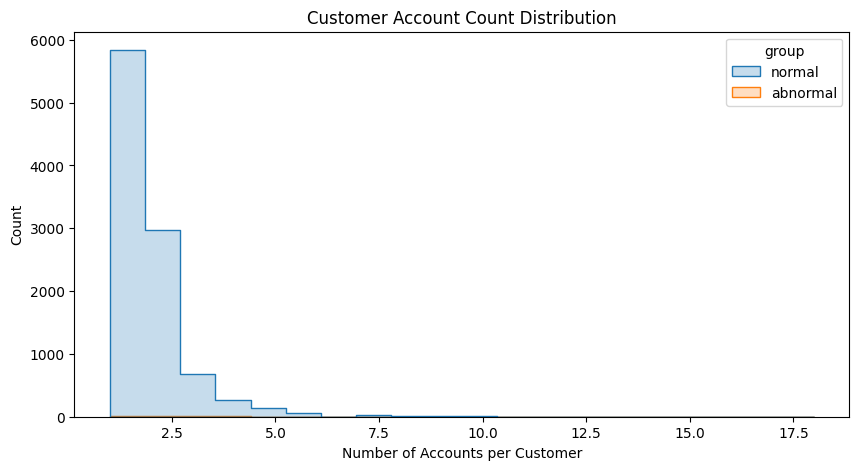

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(data=account_dist, x="num_accounts", hue="group", bins=20, element="step", stat="count", common_norm=False)
plt.title("Customer Account Count Distribution")
plt.xlabel("Number of Accounts per Customer")
plt.ylabel("Count")
plt.show()

## 8. Transaction Volume Structure

A transaction-frequency check helps determine whether transaction features should be counts, sums, or temporal summaries.

In [25]:
txn_count_normal = satxnrec_normal.groupby("ACC_RANDOM").size().reset_index(name="num_txn")
txn_count_normal["group"] = "normal"

txn_count_abnormal = satxnrec_abnormal.groupby("ACC_RANDOM").size().reset_index(name="num_txn")
txn_count_abnormal["group"] = "abnormal"

txn_dist = pd.concat([txn_count_normal, txn_count_abnormal], ignore_index=True)
txn_dist.head()

,ACC_RANDOM,num_txn,group
0,1001454,4,normal
1,100299,2,normal
2,1004323,10,normal
3,1005220,8,normal
4,1006416,2,normal


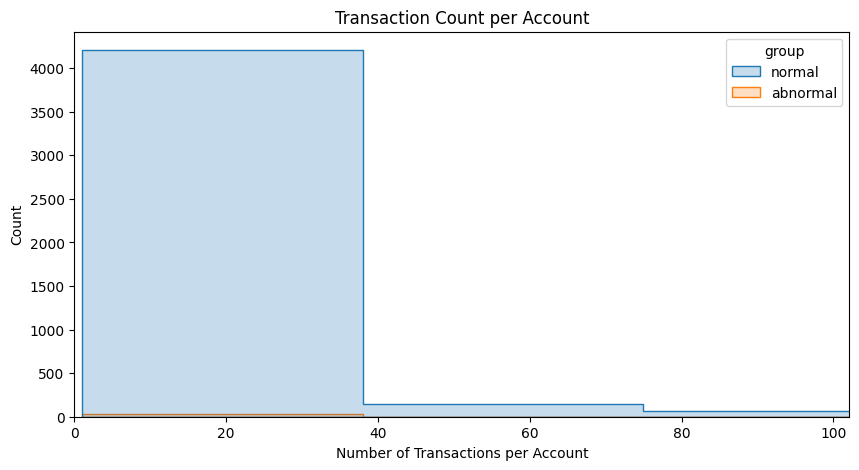

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(data=txn_dist, x="num_txn", hue="group", bins=30, element="step", stat="count", common_norm=False)
plt.title("Transaction Count per Account")
plt.xlabel("Number of Transactions per Account")
plt.ylabel("Count")
plt.xlim(0, txn_dist["num_txn"].quantile(0.99))
plt.show()